# Experiment 2 — Ảnh hưởng của learning rate

Notebook này giữ nguyên dữ liệu, kiến trúc mạng và cách đánh giá của Experiment 1 để tạo một phép so sánh công bằng. Thay đổi duy nhất là learning rate tăng từ `0.001` lên `0.01`.

## Quy trình thực hiện

1. Đọc và kiểm tra `data/diabetes.csv`.
2. Tách dữ liệu stratified thành train/validation/test theo tỷ lệ 70/15/15.
3. Chuẩn hóa 21 feature bằng thống kê của tập train.
4. Huấn luyện MLP `21 -> 64 -> 32 -> 1` với ReLU, Sigmoid và binary cross-entropy.
5. Mỗi mini-batch thực hiện lần lượt forward → tính loss → backward → cập nhật tham số.
6. Đánh giá bằng threshold `0.5` và lưu biểu đồ cùng model vào các thư mục output.

## Ý nghĩa của experiment

Learning rate quyết định độ lớn bước cập nhật trọng số. Giá trị `0.01` thường giúp loss giảm nhanh hơn trong lần chạy này, nhưng nếu quá lớn có thể gây dao động hoặc làm mô hình không hội tụ. Vì vậy, hãy đọc cả training loss và validation loss thay vì chỉ nhìn accuracy.

## Cấu hình và kết quả tham khảo

- Seed: `42`; epochs: `50`; batch size: `512`; learning rate: `0.01`.
- Train loss cuối: `0.5058`; validation loss cuối: `0.5144`.
- Accuracy: `0.7427`; precision: `0.7289`; recall: `0.7728`; F1-score: `0.7502`.

Các cell bên dưới được giữ cùng thứ tự với Experiment 1 để có thể đối chiếu trực tiếp kết quả.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [48]:
SEED = 42

np.random.seed(SEED)

DATA_PATH = Path(
    "data/diabetes.csv"
)

MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")
OUTPUT_DIR = Path("outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [49]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [50]:
print(df.columns.tolist())

['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [53]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

Duplicate rows: 1635


In [54]:
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


In [55]:
class_counts = (
    df["Diabetes_binary"]
    .value_counts()
    .sort_index()
)

print(class_counts)

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [56]:
class_percent = (
    class_counts
    / len(df)
    * 100
)

print(class_percent)

Diabetes_binary
0.0    50.0
1.0    50.0
Name: count, dtype: float64


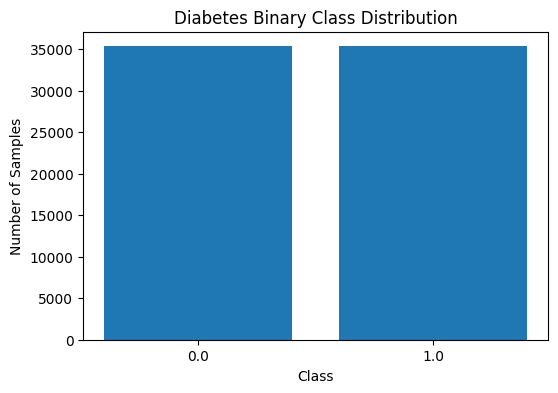

In [57]:
plt.figure(figsize=(6, 4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Diabetes Binary Class Distribution")

plt.show()

In [58]:
TARGET = "Diabetes_binary"

X = (
    df
    .drop(columns=[TARGET])
    .to_numpy(dtype=np.float32)
)

y = (
    df[TARGET]
    .to_numpy(dtype=np.float32)
    .reshape(-1, 1)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70692, 21)
y shape: (70692, 1)


In [59]:
print(
    "First patient:",
    X[0]
)

print(
    "Target:",
    y[0]
)

First patient: [ 1.  0.  1. 26.  0.  0.  0.  1.  0.  1.  0.  1.  0.  3.  5. 30.  0.  1.
  4.  6.  8.]
Target: [0.]


In [60]:
def stratified_split(
    X,
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42
):
    rng = np.random.default_rng(seed)

    y_flat = y.ravel()

    train_indices = []
    val_indices = []
    test_indices = []

    for cls in np.unique(y_flat):

        cls_indices = np.where(
            y_flat == cls
        )[0]

        rng.shuffle(cls_indices)

        n = len(cls_indices)

        n_train = int(
            train_ratio * n
        )

        n_val = int(
            val_ratio * n
        )

        train_indices.extend(
            cls_indices[:n_train]
        )

        val_indices.extend(
            cls_indices[
                n_train:n_train + n_val
            ]
        )

        test_indices.extend(
            cls_indices[
                n_train + n_val:
            ]
        )

    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return (
        X[train_indices],
        y[train_indices],

        X[val_indices],
        y[val_indices],

        X[test_indices],
        y[test_indices]
    )

In [61]:
(
    X_train,
    y_train,

    X_val,
    y_val,

    X_test,
    y_test

) = stratified_split(
    X,
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=SEED
)

In [62]:
print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    y_val.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (49484, 21) (49484, 1)
Validation: (10602, 21) (10602, 1)
Test: (10606, 21) (10606, 1)


In [63]:
def show_class_ratio(name, y):

    values, counts = np.unique(
        y,
        return_counts=True
    )

    print(name)

    for value, count in zip(
        values,
        counts
    ):
        print(
            f"Class {int(value)}: "
            f"{count} "
            f"({count / len(y) * 100:.2f}%)"
        )

    print()

In [64]:
show_class_ratio(
    "Train",
    y_train
)

show_class_ratio(
    "Validation",
    y_val
)

show_class_ratio(
    "Test",
    y_test
)

Train
Class 0: 24742 (50.00%)
Class 1: 24742 (50.00%)

Validation
Class 0: 5301 (50.00%)
Class 1: 5301 (50.00%)

Test
Class 0: 5303 (50.00%)
Class 1: 5303 (50.00%)



In [65]:
mean = X_train.mean(
    axis=0,
    keepdims=True
)

std = X_train.std(
    axis=0,
    keepdims=True
)

std = np.where(
    std < 1e-8,
    1.0,
    std
)

X_train = (
    X_train - mean
) / std

X_val = (
    X_val - mean
) / std

X_test = (
    X_test - mean
) / std

In [66]:
print(
    "Training mean:",
    X_train.mean(axis=0)[:5]
)

print(
    "Training std:",
    X_train.std(axis=0)[:5]
)

Training mean: [ 3.0313763e-07 -1.9325135e-07 -1.0606992e-06 -1.2289995e-07
 -4.7467864e-07]
Training std: [1.0003616  0.99965817 1.0004416  0.99998456 0.9998674 ]


In [67]:
def relu(x):
    return np.maximum(
        0,
        x
    )
def relu_derivative(x):
    return (
        x > 0
    ).astype(np.float32)

In [68]:
def sigmoid(x):

    x = np.clip(
        x,
        -50,
        50
    )

    return 1.0 / (
        1.0
        +
        np.exp(-x)
    )

In [69]:
def initialize_parameters(
    input_dim=21,
    hidden1=64,
    hidden2=32,
    output_dim=1,
    seed=42
):

    rng = np.random.default_rng(seed)

    W1 = (
        rng.standard_normal(
            (input_dim, hidden1)
        )
        * np.sqrt(
            2.0 / input_dim
        )
    ).astype(np.float32)

    b1 = np.zeros(
        (1, hidden1),
        dtype=np.float32
    )

    W2 = (
        rng.standard_normal(
            (hidden1, hidden2)
        )
        * np.sqrt(
            2.0 / hidden1
        )
    ).astype(np.float32)

    b2 = np.zeros(
        (1, hidden2),
        dtype=np.float32
    )

    W3 = (
        rng.standard_normal(
            (hidden2, output_dim)
        )
        * np.sqrt(
            2.0 / hidden2
        )
    ).astype(np.float32)

    b3 = np.zeros(
        (1, output_dim),
        dtype=np.float32
    )

    return {
        "W1": W1,
        "b1": b1,

        "W2": W2,
        "b2": b2,

        "W3": W3,
        "b3": b3
    }

params = initialize_parameters(
    seed=SEED
)

In [70]:
for name, value in params.items():
    print(
        name,
        value.shape
    )

W1 (21, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 1)
b3 (1, 1)


In [71]:
def forward(
    X,
    params
):

    W1 = params["W1"]
    b1 = params["b1"]

    W2 = params["W2"]
    b2 = params["b2"]

    W3 = params["W3"]
    b3 = params["b3"]

    # Layer 1
    z1 = X @ W1 + b1
    h1 = relu(z1)

    # Layer 2
    z2 = h1 @ W2 + b2
    h2 = relu(z2)

    # Output layer
    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)

    cache = {
        "X": X,

        "z1": z1,
        "h1": h1,

        "z2": z2,
        "h2": h2,

        "z3": z3,
        "y_hat": y_hat
    }

    return y_hat, cache

In [72]:
sample_X = X_train[:5]

sample_pred, sample_cache = forward(
    sample_X,
    params
)

print(
    "Prediction shape:",
    sample_pred.shape
)

print(
    sample_pred
)

Prediction shape: (5, 1)
[[0.20033458]
 [0.21322393]
 [0.3788206 ]
 [0.5104608 ]
 [0.21340688]]


In [73]:
def binary_cross_entropy(
    y,
    y_hat
):

    eps = 1e-8

    y_hat = np.clip(
        y_hat,
        eps,
        1 - eps
    )

    loss = -np.mean(
        y * np.log(y_hat)
        +
        (1 - y)
        * np.log(1 - y_hat)
    )

    return loss

In [74]:
sample_loss = binary_cross_entropy(
    y_train[:5],
    sample_pred
)

print(
    "Initial loss:",
    sample_loss
)

Initial loss: 0.6556096


In [75]:
def backward(
    y,
    cache,
    params
):

    X = cache["X"]

    z1 = cache["z1"]
    h1 = cache["h1"]

    z2 = cache["z2"]
    h2 = cache["h2"]

    y_hat = cache["y_hat"]

    W2 = params["W2"]
    W3 = params["W3"]

    n = len(X)

    # =========================
    # OUTPUT LAYER
    # =========================

    dz3 = (
        y_hat - y
    ) / n

    dW3 = (
        h2.T @ dz3
    )

    db3 = np.sum(
        dz3,
        axis=0,
        keepdims=True
    )

    # =========================
    # HIDDEN LAYER 2
    # =========================

    dh2 = (
        dz3 @ W3.T
    )

    dz2 = (
        dh2
        *
        relu_derivative(z2)
    )

    dW2 = (
        h1.T @ dz2
    )

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    # =========================
    # HIDDEN LAYER 1
    # =========================

    dh1 = (
        dz2 @ W2.T
    )

    dz1 = (
        dh1
        *
        relu_derivative(z1)
    )

    dW1 = (
        X.T @ dz1
    )

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    return {
        "W1": dW1,
        "b1": db1,

        "W2": dW2,
        "b2": db2,

        "W3": dW3,
        "b3": db3
    }

In [76]:
sample_gradients = backward(
    y_train[:5],
    sample_cache,
    params
)

for name, value in sample_gradients.items():

    print(
        name,
        value.shape
    )

W1 (21, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 1)
b3 (1, 1)


In [77]:
def update_parameters(
    params,
    gradients,
    learning_rate
):

    for key in params:

        params[key] -= (
            learning_rate
            *
            gradients[key]
        )

In [78]:
def create_mini_batches(
    X,
    y,
    batch_size,
    rng
):

    indices = rng.permutation(
        len(X)
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):

        batch_indices = indices[
            start:
            start + batch_size
        ]

        yield (
            X[batch_indices],
            y[batch_indices]
        )

In [79]:
# learning_rate = 0.001 #exp1
learning_rate = 0.01 #exp 2
epochs = 50
batch_size = 512

rng = np.random.default_rng(
    SEED
)

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    batch_losses = []

    for X_batch, y_batch in create_mini_batches(
        X_train,
        y_train,
        batch_size,
        rng
    ):

        # =====================
        # 1. FORWARD
        # =====================

        y_hat, cache = forward(
            X_batch,
            params
        )

        # =====================
        # 2. LOSS
        # =====================

        loss = binary_cross_entropy(
            y_batch,
            y_hat
        )

        batch_losses.append(
            loss
        )

        # =====================
        # 3. BACKWARD
        # =====================

        gradients = backward(
            y_batch,
            cache,
            params
        )

        # =====================
        # 4. UPDATE
        # =====================

        update_parameters(
            params,
            gradients,
            learning_rate
        )

    # =========================
    # TRAIN LOSS
    # =========================

    train_loss = np.mean(
        batch_losses
    )

    # =========================
    # VALIDATION LOSS
    # =========================

    val_pred, _ = forward(
        X_val,
        params
    )

    val_loss = binary_cross_entropy(
        y_val,
        val_pred
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}"
    )

Epoch 01/50 | Train Loss = 0.6936 | Val Loss = 0.6412
Epoch 02/50 | Train Loss = 0.6216 | Val Loss = 0.5994
Epoch 03/50 | Train Loss = 0.5893 | Val Loss = 0.5769
Epoch 04/50 | Train Loss = 0.5699 | Val Loss = 0.5630
Epoch 05/50 | Train Loss = 0.5573 | Val Loss = 0.5538
Epoch 06/50 | Train Loss = 0.5484 | Val Loss = 0.5473
Epoch 07/50 | Train Loss = 0.5419 | Val Loss = 0.5425
Epoch 08/50 | Train Loss = 0.5370 | Val Loss = 0.5389
Epoch 09/50 | Train Loss = 0.5334 | Val Loss = 0.5361
Epoch 10/50 | Train Loss = 0.5304 | Val Loss = 0.5338
Epoch 11/50 | Train Loss = 0.5283 | Val Loss = 0.5320
Epoch 12/50 | Train Loss = 0.5264 | Val Loss = 0.5304
Epoch 13/50 | Train Loss = 0.5246 | Val Loss = 0.5290
Epoch 14/50 | Train Loss = 0.5229 | Val Loss = 0.5279
Epoch 15/50 | Train Loss = 0.5216 | Val Loss = 0.5270
Epoch 16/50 | Train Loss = 0.5205 | Val Loss = 0.5260
Epoch 17/50 | Train Loss = 0.5194 | Val Loss = 0.5251
Epoch 18/50 | Train Loss = 0.5184 | Val Loss = 0.5244
Epoch 19/50 | Train Loss = 0

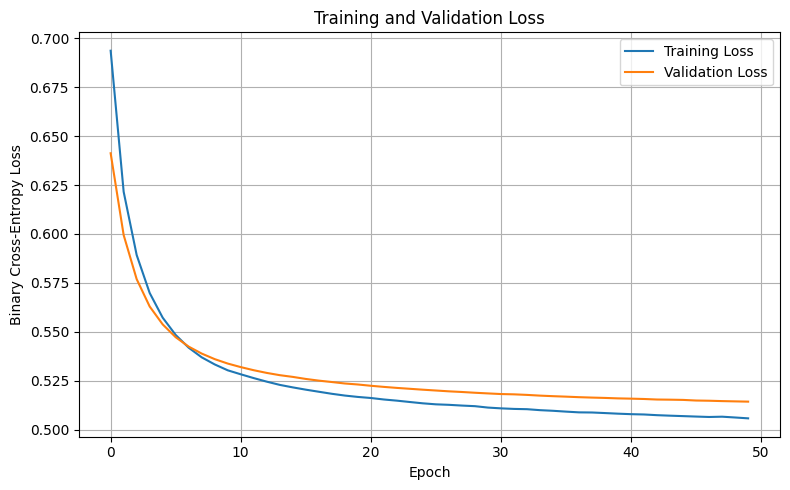

In [80]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_loss_history,
    label="Training Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "loss_curve-exp2.png",
    dpi=150
)

plt.show()

In [81]:
test_prob, _ = forward(
    X_test,
    params
)

y_pred = (
    test_prob >= 0.5
).astype(np.float32)

In [82]:
accuracy = np.mean(
    y_pred == y_test
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.7427


In [83]:
TP = np.sum(
    (y_pred == 1)
    &
    (y_test == 1)
)

TN = np.sum(
    (y_pred == 0)
    &
    (y_test == 0)
)

FP = np.sum(
    (y_pred == 1)
    &
    (y_test == 0)
)

FN = np.sum(
    (y_pred == 0)
    &
    (y_test == 1)
)

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 4098
TN: 3779
FP: 1524
FN: 1205


In [84]:
eps = 1e-8

precision = (
    TP /
    (TP + FP + eps)
)

recall = (
    TP /
    (TP + FN + eps)
)

f1 = (
    2
    * precision
    * recall
    /
    (
        precision
        +
        recall
        +
        eps
    )
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

Accuracy : 0.7427
Precision: 0.7289
Recall   : 0.7728
F1-score : 0.7502


In [85]:
confusion_matrix = np.array(
    [
        [TN, FP],
        [FN, TP]
    ]
)

print(
    confusion_matrix
)

[[3779 1524]
 [1205 4098]]


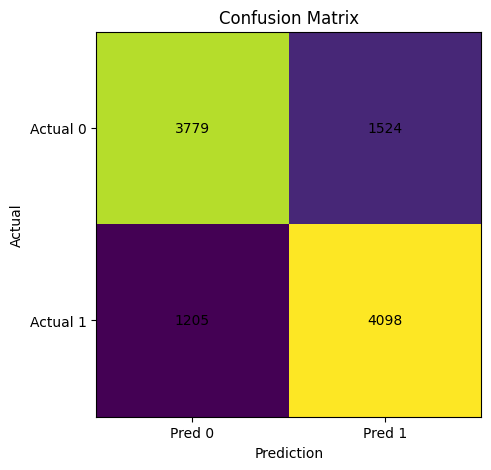

In [86]:
plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    confusion_matrix
)

plt.xticks(
    [0, 1],
    ["Pred 0", "Pred 1"]
)

plt.yticks(
    [0, 1],
    ["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "confusion_matrix-exp2.png",
    dpi=150
)

plt.show()

In [87]:
for i in range(10):

    print(
        f"Patient {i + 1:02d} | "
        f"Probability = {test_prob[i, 0]:.4f} | "
        f"Prediction = {int(y_pred[i, 0])} | "
        f"Actual = {int(y_test[i, 0])}"
    )

Patient 01 | Probability = 0.8791 | Prediction = 1 | Actual = 1
Patient 02 | Probability = 0.8145 | Prediction = 1 | Actual = 1
Patient 03 | Probability = 0.8613 | Prediction = 1 | Actual = 1
Patient 04 | Probability = 0.7580 | Prediction = 1 | Actual = 1
Patient 05 | Probability = 0.9066 | Prediction = 1 | Actual = 1
Patient 06 | Probability = 0.0482 | Prediction = 0 | Actual = 0
Patient 07 | Probability = 0.1467 | Prediction = 0 | Actual = 0
Patient 08 | Probability = 0.0576 | Prediction = 0 | Actual = 0
Patient 09 | Probability = 0.7755 | Prediction = 1 | Actual = 0
Patient 10 | Probability = 0.6044 | Prediction = 1 | Actual = 0


In [88]:
_, representation_cache = forward(
    X_test,
    params
)

H1 = representation_cache["h1"]
H2 = representation_cache["h2"]

print(
    "Original representation:",
    X_test.shape
)

print(
    "Hidden representation H1:",
    H1.shape
)

print(
    "Hidden representation H2:",
    H2.shape
)

Original representation: (10606, 21)
Hidden representation H1: (10606, 64)
Hidden representation H2: (10606, 32)


In [89]:
MODEL_PATH = (
    MODEL_DIR
    /
    "diabetes_numpy_mlp-exp2.npz"
)

np.savez(
    MODEL_PATH,

    W1=params["W1"],
    b1=params["b1"],

    W2=params["W2"],
    b2=params["b2"],

    W3=params["W3"],
    b3=params["b3"],

    mean=mean,
    std=std,

    threshold=np.array([0.5])
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: models\diabetes_numpy_mlp-exp2.npz


In [90]:
saved = np.load(
    MODEL_PATH
)

loaded_params = {
    "W1": saved["W1"],
    "b1": saved["b1"],

    "W2": saved["W2"],
    "b2": saved["b2"],

    "W3": saved["W3"],
    "b3": saved["b3"]
}

loaded_mean = saved["mean"]
loaded_std = saved["std"]

print(
    "Model loaded successfully."
)

Model loaded successfully.


In [91]:
def predict_new_patient(
    raw_features,
    params,
    mean,
    std,
    threshold=0.5
):

    x = np.asarray(
        raw_features,
        dtype=np.float32
    ).reshape(1, -1)

    x_scaled = (
        x - mean
    ) / std

    probability, _ = forward(
        x_scaled,
        params
    )

    probability = float(
        probability[0, 0]
    )

    prediction = int(
        probability >= threshold
    )

    return (
        probability,
        prediction
    )